# Read and Inspect PLY Files

This notebook loads `.ply` files (3D Gaussian Splatting format) and inspects their contents —
vertex properties, statistics, and a basic 3D scatter plot.

In [1]:
# Install plyfile if not already available
try:
    from plyfile import PlyData
except ImportError:
    %pip install plyfile
    from plyfile import PlyData

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

  Using cached plyfile-1.1.3-py3-none-any.whl.metadata (43 kB)
Note: you may need to restart the kernel to use updated packages.


## 1. Choose a PLY file to load

Change `ply_path` below to point at the file you want to inspect.  
A few options available in this workspace:

| File | Description |
|------|-------------|
| `dataset/abdomen.ply` | Abdomen dataset |
| `checkpoints/gsplat_ckpt/gsplat_final.ply` | Trained gsplat output |
| `3DGS_PLY_sample_data/PLY(postshot)/cactus_splat3_30kSteps_142k_splats.ply` | Cactus sample (142 k splats) |

In [7]:
ply_path = "3DGS_PLY_sample_data/PLY(postshot)/cactus_splat3_30kSteps_719k_splats.ply"  # <-- change this to your file

plydata = PlyData.read(ply_path)
print(f"Loaded: {ply_path}")
print(f"Elements: {[el.name for el in plydata.elements]}")
for el in plydata.elements:
    print(f"  {el.name}: {el.count} entries, properties: {[p.name for p in el.properties]}")

Loaded: 3DGS_PLY_sample_data/PLY(postshot)/cactus_splat3_30kSteps_719k_splats.ply
Elements: ['vertex']
  vertex: 695779 entries, properties: ['x', 'y', 'z', 'f_dc_0', 'f_dc_1', 'f_dc_2', 'f_rest_0', 'f_rest_1', 'f_rest_2', 'f_rest_3', 'f_rest_4', 'f_rest_5', 'f_rest_6', 'f_rest_7', 'f_rest_8', 'f_rest_9', 'f_rest_10', 'f_rest_11', 'f_rest_12', 'f_rest_13', 'f_rest_14', 'f_rest_15', 'f_rest_16', 'f_rest_17', 'f_rest_18', 'f_rest_19', 'f_rest_20', 'f_rest_21', 'f_rest_22', 'f_rest_23', 'f_rest_24', 'f_rest_25', 'f_rest_26', 'f_rest_27', 'f_rest_28', 'f_rest_29', 'f_rest_30', 'f_rest_31', 'f_rest_32', 'f_rest_33', 'f_rest_34', 'f_rest_35', 'f_rest_36', 'f_rest_37', 'f_rest_38', 'f_rest_39', 'f_rest_40', 'f_rest_41', 'f_rest_42', 'f_rest_43', 'f_rest_44', 'opacity', 'scale_0', 'scale_1', 'scale_2', 'rot_0', 'rot_1', 'rot_2', 'rot_3']


## 2. Convert vertex data to a DataFrame

In [8]:
vertex = plydata["vertex"]
property_names = [p.name for p in vertex.properties]
print(f"Properties ({len(property_names)}): {property_names}")

# Build a DataFrame from all vertex properties
df = pd.DataFrame({name: vertex[name] for name in property_names})
df.head(10)

Properties (59): ['x', 'y', 'z', 'f_dc_0', 'f_dc_1', 'f_dc_2', 'f_rest_0', 'f_rest_1', 'f_rest_2', 'f_rest_3', 'f_rest_4', 'f_rest_5', 'f_rest_6', 'f_rest_7', 'f_rest_8', 'f_rest_9', 'f_rest_10', 'f_rest_11', 'f_rest_12', 'f_rest_13', 'f_rest_14', 'f_rest_15', 'f_rest_16', 'f_rest_17', 'f_rest_18', 'f_rest_19', 'f_rest_20', 'f_rest_21', 'f_rest_22', 'f_rest_23', 'f_rest_24', 'f_rest_25', 'f_rest_26', 'f_rest_27', 'f_rest_28', 'f_rest_29', 'f_rest_30', 'f_rest_31', 'f_rest_32', 'f_rest_33', 'f_rest_34', 'f_rest_35', 'f_rest_36', 'f_rest_37', 'f_rest_38', 'f_rest_39', 'f_rest_40', 'f_rest_41', 'f_rest_42', 'f_rest_43', 'f_rest_44', 'opacity', 'scale_0', 'scale_1', 'scale_2', 'rot_0', 'rot_1', 'rot_2', 'rot_3']


,x,y,z,f_dc_0,f_dc_1,f_dc_2,f_rest_0,f_rest_1,f_rest_2,f_rest_3,...,f_rest_43,f_rest_44,opacity,scale_0,scale_1,scale_2,rot_0,rot_1,rot_2,rot_3
0,-0.370412,-0.541317,0.431100,-0.169351,-0.790180,-1.108977,0.087349,-0.110521,-0.087778,0.017747,...,-0.069825,-0.112520,0.419832,-7.857850,-5.736915,-4.729513,0.960414,0.063420,0.127350,0.239509
1,0.153319,-0.731009,0.199324,0.974780,0.586104,0.457084,0.146752,-0.025065,-0.072454,0.166670,...,0.013599,0.040798,0.199922,-7.844676,-4.224890,-2.986104,0.950544,-0.138493,0.269652,-0.067631
2,0.646494,-1.076635,0.008846,0.276151,-0.480518,-0.906145,0.010083,0.039235,0.079242,-0.049496,...,0.002494,0.068041,1.485885,-4.649471,-8.006392,-3.223475,0.985498,0.028722,0.094850,0.137739
3,0.162804,-0.877433,-0.399401,-0.514311,-1.160827,-1.633954,0.073333,0.109430,0.052034,0.006371,...,-0.067783,-0.000798,-0.848632,-5.231609,-6.497215,-7.266126,0.962855,0.194739,-0.163177,-0.091432
4,-0.373923,-0.267896,-0.128527,0.051883,-0.101245,-0.134520,0.105937,0.048629,-0.079799,-0.014686,...,0.006722,-0.174255,-0.442822,-6.532976,-6.958706,-6.413903,0.832359,-0.312206,0.356205,-0.287792
5,0.475036,-0.689937,-0.119121,-0.468337,-0.940881,-1.339535,0.029534,0.046978,0.072829,-0.030032,...,-0.015093,-0.193822,-1.069955,-6.626173,-6.851277,-4.670355,0.894380,0.120070,0.282449,-0.325407
6,0.273462,-1.067584,-0.481255,0.349337,0.170055,0.164670,0.068736,0.131011,0.019064,-0.014012,...,0.214978,-0.019166,1.621768,-4.264865,-7.911819,-7.936315,0.985779,-0.114601,-0.121642,-0.017570
7,0.301726,-1.871573,0.001944,-0.739326,-0.891787,-1.226650,-0.044700,0.016227,0.281810,-0.256557,...,-0.013528,0.095116,0.397274,-6.040742,-8.700986,-5.568726,0.952850,0.087450,0.133584,-0.258040
8,0.268365,0.099978,-0.750186,-0.582651,-0.548784,-0.530847,0.073263,0.140841,0.128432,-0.077517,...,0.174989,0.069284,2.860538,-7.782514,-4.744144,-5.716018,0.996167,-0.025389,0.041374,0.072771
9,0.055235,-0.996566,0.703145,0.053384,-0.540626,-0.972681,-0.030514,-0.131024,-0.012041,0.005664,...,0.023573,0.092927,1.757371,-5.136700,-4.973639,-7.705810,0.969671,-0.150850,-0.001271,-0.192302


## 3. Basic statistics

In [9]:
print(f"Number of vertices (splats): {len(df):,}")
print()
df.describe()

Number of vertices (splats): 695,779



,x,y,z,f_dc_0,f_dc_1,f_dc_2,f_rest_0,f_rest_1,f_rest_2,f_rest_3,...,f_rest_43,f_rest_44,opacity,scale_0,scale_1,scale_2,rot_0,rot_1,rot_2,rot_3
count,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,...,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000,695779.000000
mean,0.045222,-0.857689,0.111238,-0.290547,-0.433046,-0.671869,-0.005112,-0.005422,0.002795,-0.001010,...,0.000548,0.000186,-0.280673,-6.169503,-6.232054,-6.169786,0.881702,-0.053073,0.018494,-0.003593
std,0.356231,0.730286,0.353944,0.723619,0.702465,0.743467,0.065558,0.068177,0.065960,0.064888,...,0.076803,0.076055,1.483900,1.213433,1.158381,1.207420,0.140793,0.255244,0.266127,0.252258
min,-0.860300,-1.954868,-0.763893,-2.261854,-2.164486,-2.387669,-0.543917,-0.525437,-0.501362,-0.551481,...,-0.490784,-0.512256,-3.922321,-10.872268,-11.371230,-11.172886,-0.499989,-0.865299,-0.858631,-0.860879
25%,-0.209521,-1.492219,-0.168097,-0.866930,-0.985231,-1.229809,-0.040744,-0.043684,-0.033734,-0.033846,...,-0.045770,-0.044297,-1.393096,-7.162920,-7.143020,-7.141235,0.843174,-0.207283,-0.166318,-0.152810
50%,0.056583,-1.032714,0.099056,-0.295486,-0.536882,-0.795150,0.000426,-0.004341,0.002666,-0.000423,...,0.000000,0.000000,-0.397413,-6.075212,-6.217129,-6.076880,0.920136,-0.045974,0.028329,-0.003991
75%,0.318009,0.010428,0.361154,0.208124,0.032496,-0.185428,0.036597,0.033544,0.039334,0.032359,...,0.047710,0.044689,0.711025,-5.252727,-5.348454,-5.259466,0.963243,0.095585,0.209763,0.142933
max,0.910244,0.583841,1.018691,3.807856,3.305554,3.867180,0.339000,0.566105,0.495479,0.529034,...,0.492251,0.531447,7.727737,-1.840847,-2.249848,-2.025988,0.999996,0.992253,0.999436,0.990181


## 4. 3D scatter plot of Gaussian centres

Plots the `(x, y, z)` positions. For large point clouds the plot is sub-sampled.

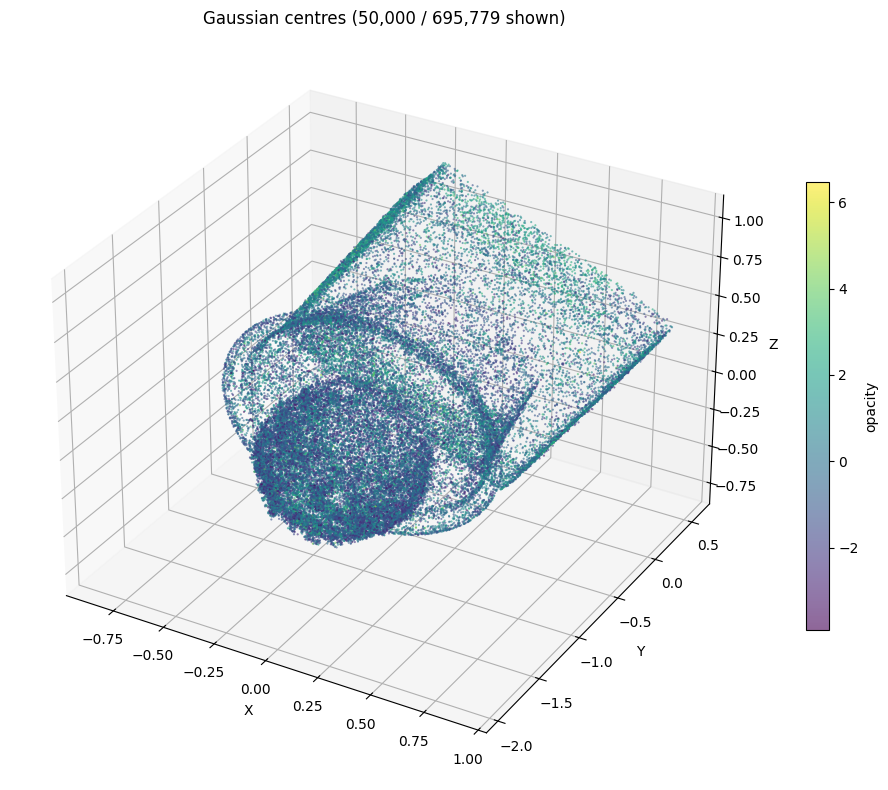

In [10]:
MAX_POINTS = 50_000  # subsample for plotting speed

xyz_cols = ["x", "y", "z"]
if all(c in df.columns for c in xyz_cols):
    sub = df if len(df) <= MAX_POINTS else df.sample(MAX_POINTS, random_state=42)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Colour by opacity if available, otherwise by z
    if "opacity" in df.columns:
        c = sub["opacity"]
        label = "opacity"
    else:
        c = sub["z"]
        label = "z"

    sc = ax.scatter(sub["x"], sub["y"], sub["z"], c=c, s=0.3, alpha=0.6, cmap="viridis")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"Gaussian centres ({len(sub):,} / {len(df):,} shown)")
    plt.colorbar(sc, label=label, shrink=0.6)
    plt.tight_layout()
    plt.show()
else:
    print(f"Columns 'x', 'y', 'z' not found. Available: {list(df.columns)}")

## 4b. Interactive Intensity-Channel Viewer (gsplat + viser, HTTPS)

Renders the RGB model as **separate intensity channels** (no alpha). Each channel (R, G, B) is
rendered independently as a grayscale intensity image using `gsplat.rasterization`.

Modes (selectable in the GUI):
- **All** - 2x2 grid: R (red tint) | G (green tint) | B (blue tint) | RGB composite
- **R / G / B** - single channel as greyscale
- **RGB** - standard colour composite

Open **https://localhost:8443** (or http://localhost:8080) after running.

In [ ]:
import torch, math, time, os, asyncio, ssl, threading, subprocess, socket
import torch.nn.functional as F
import gsplat
import viser

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ===================== SETTINGS =====================
IMG_H, IMG_W = 800, 800
MAX_SPLATS   = None          # None = use all splats
VISER_PORT   = 8080
HTTPS_PORT   = 8443
NEAR, FAR    = 0.01, 100.0
CERT_DIR     = "/tmp/viser_ssl"
# ====================================================

# ---------- free ports from previous runs ----------
for _port in [VISER_PORT, HTTPS_PORT]:
    try:
        _s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        _s.settimeout(1); _s.bind(("0.0.0.0", _port)); _s.close()
    except OSError:
        os.system(f"fuser -k {_port}/tcp 2>/dev/null")
        time.sleep(0.5)

# ---------- SSL cert ----------
os.makedirs(CERT_DIR, exist_ok=True)
cert_file = os.path.join(CERT_DIR, "cert.pem")
key_file  = os.path.join(CERT_DIR, "key.pem")
if not (os.path.exists(cert_file) and os.path.exists(key_file)):
    subprocess.run(["openssl", "req", "-x509", "-newkey", "rsa:2048",
                     "-keyout", key_file, "-out", cert_file,
                     "-days", "365", "-nodes", "-subj", "/CN=localhost"],
                    check=True, capture_output=True)
    print(f"Generated SSL cert: {cert_file}")
else:
    print(f"Reusing SSL cert from {CERT_DIR}")

# ---------- TCP-level SSL proxy (handles HTTP + WebSocket) ----------
def start_ssl_proxy(viser_port, https_port):
    ssl_ctx = ssl.SSLContext(ssl.PROTOCOL_TLS_SERVER)
    ssl_ctx.load_cert_chain(cert_file, key_file)

    async def pipe(r, w):
        try:
            while True:
                data = await r.read(65536)
                if not data: break
                w.write(data); await w.drain()
        except: pass
        finally: w.close()

    async def handle(cr, cw):
        try:
            ur, uw = await asyncio.open_connection("127.0.0.1", viser_port)
        except OSError:
            cw.close(); return
        await asyncio.gather(pipe(cr, uw), pipe(ur, cw))

    async def serve():
        srv = await asyncio.start_server(handle, "0.0.0.0", https_port, ssl=ssl_ctx)
        async with srv: await srv.serve_forever()

    def run():
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(serve())

    threading.Thread(target=run, daemon=True).start()
    print(f"HTTPS/WSS proxy: https://localhost:{https_port}")

# ---------- load PLY data into torch tensors ----------
_sub = df if (MAX_SPLATS is None or len(df) <= MAX_SPLATS) else df.sample(MAX_SPLATS, random_state=42)
N = len(_sub)

means = torch.tensor(np.stack([_sub["x"].values, _sub["y"].values, _sub["z"].values], axis=-1),
                      dtype=torch.float32, device=device)
log_scales_t = torch.tensor(np.stack([_sub["scale_0"].values, _sub["scale_1"].values, _sub["scale_2"].values], axis=-1),
                             dtype=torch.float32, device=device)
scales = torch.exp(log_scales_t).clamp(1e-6, 10.0)
quats = F.normalize(torch.tensor(np.stack([_sub["rot_0"].values, _sub["rot_1"].values,
                                            _sub["rot_2"].values, _sub["rot_3"].values], axis=-1),
                                  dtype=torch.float32, device=device), dim=-1)

# Split RGB into per-channel intensities
if all(c in _sub.columns for c in ["f_dc_0", "f_dc_1", "f_dc_2"]):
    sh_dc = torch.tensor(np.stack([_sub["f_dc_0"].values, _sub["f_dc_1"].values, _sub["f_dc_2"].values], axis=-1),
                          dtype=torch.float32, device=device)
    colors_rgb = torch.sigmoid(sh_dc)  # (N, 3)
else:
    colors_rgb = torch.full((N, 3), 0.5, device=device)

colors_r = colors_rgb[:, 0:1]  # (N, 1) red intensity
colors_g = colors_rgb[:, 1:2]  # (N, 1) green intensity
colors_b = colors_rgb[:, 2:3]  # (N, 1) blue intensity

# No alpha - all opacities set to 1
opacities = torch.ones(N, device=device)

print(f"Loaded {N:,} splats onto {device} (intensity mode, no alpha)")

# ---------- scene geometry ----------
centroid = means.mean(dim=0)
scene_radius = (means - centroid).norm(dim=-1).quantile(0.95).item()
cam_dist = scene_radius * 2.5

fov_y = math.radians(60.0)
fy = IMG_H / (2.0 * math.tan(fov_y / 2.0)); fx = fy
K_intr = torch.tensor([[fx, 0, IMG_W/2.0], [0, fy, IMG_H/2.0], [0, 0, 1.0]], device=device)

channel_map = {"R": colors_r, "G": colors_g, "B": colors_b, "RGB": colors_rgb}

# ---------- render functions ----------
@torch.no_grad()
def render_channel(viewmat, ch_colors):
    n_ch = ch_colors.shape[1]
    mode = "RGB" if n_ch == 3 else "N"
    renders, _, _ = gsplat.rasterization(
        means=means, quats=quats, scales=scales,
        opacities=opacities, colors=ch_colors,
        viewmats=viewmat.unsqueeze(0), Ks=K_intr.unsqueeze(0),
        width=IMG_W, height=IMG_H,
        near_plane=NEAR, far_plane=FAR,
        render_mode=mode, packed=True, rasterize_mode="antialiased",
    )
    return renders[0].clamp(0, 1)

@torch.no_grad()
def render_view(viewmat, mode="All"):
    if mode in ("R", "G", "B"):
        grey = render_channel(viewmat, channel_map[mode])  # (H,W,1)
        img = grey.expand(-1, -1, 3)
    elif mode == "RGB":
        img = render_channel(viewmat, colors_rgb)
    else:  # "All" - 2x2 grid
        r = render_channel(viewmat, colors_r)
        g = render_channel(viewmat, colors_g)
        b = render_channel(viewmat, colors_b)
        rgb = render_channel(viewmat, colors_rgb)
        r_tinted = torch.cat([r, r*0, r*0], dim=-1)
        g_tinted = torch.cat([g*0, g, g*0], dim=-1)
        b_tinted = torch.cat([b*0, b*0, b], dim=-1)
        top = torch.cat([r_tinted, g_tinted], dim=1)
        bot = torch.cat([b_tinted, rgb], dim=1)
        img = torch.cat([top, bot], dim=0)
    return (img * 255).to(torch.uint8).cpu().numpy()

# ---------- viser camera -> viewmat ----------
def cam_to_viewmat(cam_handle):
    pos = np.asarray(cam_handle.position, dtype=np.float64)
    look = np.asarray(cam_handle.look_at, dtype=np.float64)
    up_dir = np.asarray(cam_handle.up_direction, dtype=np.float64)
    fwd = look - pos; fn = np.linalg.norm(fwd)
    fwd = fwd / fn if fn > 1e-8 else np.array([0., 0., -1.])
    right = np.cross(fwd, up_dir); rn = np.linalg.norm(right)
    right = right / rn if rn > 1e-8 else np.array([1., 0., 0.])
    up = np.cross(right, fwd)
    R = np.stack([right, -up, fwd], axis=0); t = R @ (-pos)
    vm = np.eye(4, dtype=np.float64); vm[:3, :3] = R; vm[:3, 3] = t
    return torch.tensor(vm, dtype=torch.float32, device=device)

# ---------- start viser server ----------
server = viser.ViserServer(host="0.0.0.0", port=VISER_PORT)
actual_port = server._websock_server.port if hasattr(server._websock_server, 'port') else VISER_PORT

# Start HTTPS proxy after viser (so we know the actual port)
start_ssl_proxy(actual_port, HTTPS_PORT)

c = centroid.cpu().numpy()
server.initial_camera.position = (c[0], c[1], c[2] + cam_dist)
server.initial_camera.look_at = (float(c[0]), float(c[1]), float(c[2]))
server.initial_camera.fov = fov_y
server.initial_camera.up_direction = (0.0, 0.0, 1.0)

status = server.gui.add_markdown(
    f"**PLY Viewer** | {N:,} splats | {IMG_W}x{IMG_H} | Intensity mode (no alpha)"
)

with server.gui.add_folder("Channel"):
    channel_select = server.gui.add_dropdown(
        "View", options=["All", "R", "G", "B", "RGB"], initial_value="All"
    )

# Warm-up
vm0 = cam_to_viewmat(server.initial_camera)
init_frame = render_view(vm0, channel_select.value)
torch.cuda.synchronize()
server.scene.set_background_image(init_frame, format="jpeg", jpeg_quality=90)
print("Warm-up render done.")

# Shared state
client_cams = {}

def do_render(client):
    cam = client_cams.get(client.client_id)
    if cam is None: return
    t0 = time.time()
    vm = cam_to_viewmat(cam)
    mode = channel_select.value
    frame = render_view(vm, mode)
    torch.cuda.synchronize()
    ms = (time.time() - t0) * 1000
    client.scene.set_background_image(frame, format="jpeg", jpeg_quality=85)
    status.content = (f"**PLY Viewer** | {N:,} splats | Ch: {mode} | "
                      f"{ms:.0f} ms ({1000/max(ms,1):.0f} FPS)")

@channel_select.on_update
def _(_):
    for client in server.get_clients().values():
        do_render(client)

@server.on_client_connect
def on_connect(client: viser.ClientHandle) -> None:
    @client.camera.on_update
    def _(cam_handle) -> None:
        client_cams[client.client_id] = cam_handle
        do_render(client)

print(f"\n=== Interactive Intensity-Channel Viewer ===")
print(f"  HTTPS: https://localhost:{HTTPS_PORT}")
print(f"  HTTP:  http://localhost:{actual_port}")
print(f"  {N:,} splats, {IMG_W}x{IMG_H}, intensity mode (no alpha)")
print(f"  Channel selector in GUI sidebar")
print(f"  Interrupt the kernel to stop.\n")

Using device: cuda
Generating self-signed SSL certificate...
  Certificate: /tmp/viser_ssl/cert.pem
  Key: /tmp/viser_ssl/key.pem
HTTPS reverse proxy running on port 8443
Loaded 695,779 splats onto cuda


╭────── viser (listening *:8083) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8083   │
│   Websocket │ ws://localhost:8083     │
│             ╵                         │
╰───────────────────────────────────────╯

Warm-up render done.

=== Interactive Gaussian Splat Viewer (HTTPS) ===
  HTTPS: https://localhost:8443  (accept self-signed cert)
  HTTP:  http://localhost:8080   (fallback)
  695,779 splats, 800x800, gsplat rasterization
  Drag to rotate, scroll to zoom, right-click to pan
  Interrupt the kernel to stop.



: 

## 5. Inspect spherical-harmonic / colour coefficients (if present)

In [6]:
sh_cols = [c for c in df.columns if c.startswith("f_rest_") or c.startswith("f_dc_")]
scale_cols = [c for c in df.columns if c.startswith("scale_")]
rot_cols = [c for c in df.columns if c.startswith("rot_")]

print(f"SH coefficients:  {len(sh_cols)}  (DC + rest)")
print(f"Scale components:  {len(scale_cols)}")
print(f"Rotation quats:   {len(rot_cols)}")

if "opacity" in df.columns:
    print(f"\nOpacity range: [{df['opacity'].min():.4f}, {df['opacity'].max():.4f}]")

if scale_cols:
    print(f"Scale stats (log-space):")
    print(df[scale_cols].describe())

SH coefficients:  48  (DC + rest)
Scale components:  3
Rotation quats:   4

Opacity range: [-5.6207, 6.9568]
Scale stats (log-space):
             scale_0        scale_1        scale_2
count  436838.000000  436838.000000  436838.000000
mean       -0.513292      -0.556128       0.359322
std         1.798557       1.851902       0.963376
min       -10.785721     -10.272305      -7.979300
25%        -1.582038      -1.490113      -0.181500
50%        -0.233786      -0.231309       0.412171
75%         0.860891       0.781343       0.999256
max         3.869486       6.005352       3.932388
